In [15]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [135]:
buildings_df = pd.read_csv('../Cleaned_data/buildings_clean.csv')
lights_df = pd.read_csv('../Cleaned_data/lights_clean.csv')
furniture_df = pd.read_csv('../Cleaned_data/street_inf_clean.csv')
bikes_df = pd.read_csv('../Cleaned_data/bikes_clean.csv')
landmarks_gdf = pd.read_csv('../Cleaned_data/landmarks_clean.csv')

## Buildings

In [140]:
buildings_df.loc[buildings_df["building_use"].isin(["Residential Apartment", 'House/Townhouse', 'Commercial Accommodation',
                                                'Student Accommodation', 'Institutional Accommodation']), "building_use"] = "Residential"
buildings_df.loc[buildings_df["building_use"].str.contains('Unoccupied'), "building_use"] = "Unoccupied"
buildings_df.loc[buildings_df["building_use"].isin(['Retail - Shop', 'Retail - Stall', 'Retail - Showroom', 'Retail - Cars',
                                                'Wholesale']), "building_use"] = "Retail"
buildings_df.loc[buildings_df["building_use"].isin(['Parking - Commercial Covered', 'Parking - Private Covered']),
                 "building_use"] = "Parking"
buildings_df.loc[buildings_df["building_use"].isin(['Workshop/Studio', 'Manufacturing', 'Equipment Installation']),
                 "building_use"] = "Working"                                                   

<AxesSubplot:>

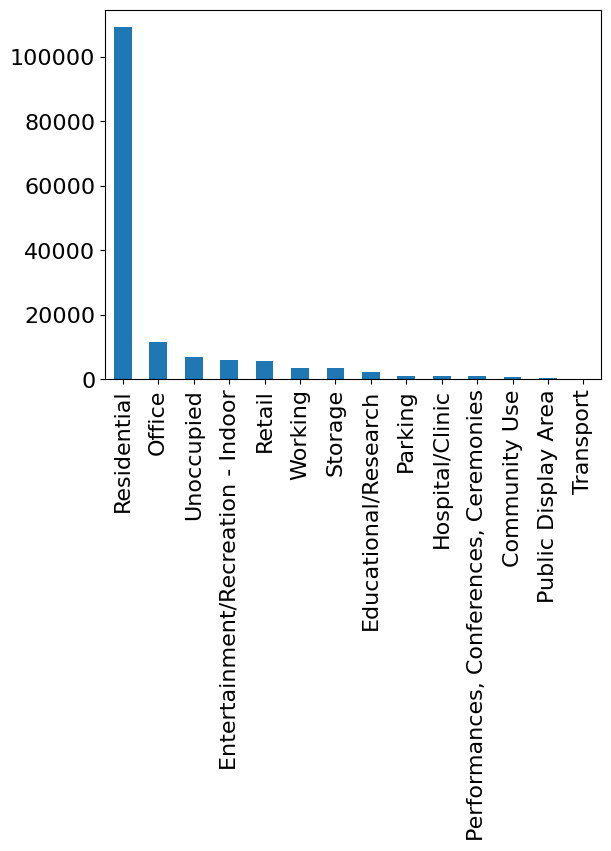

In [141]:
buildings_df['building_use'].value_counts().plot(kind='bar')

## Find which building types are the big ones??

In [153]:
# plt.scatter(buildings_df['building_use'], buildings_df['n_floors'])

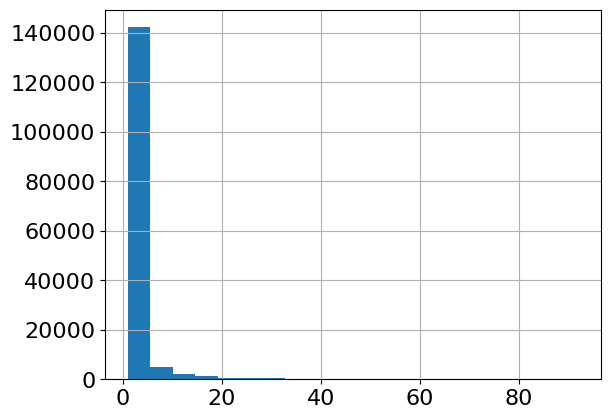

In [160]:
hist = buildings_df['n_floors'].hist(bins=20)

<AxesSubplot:>

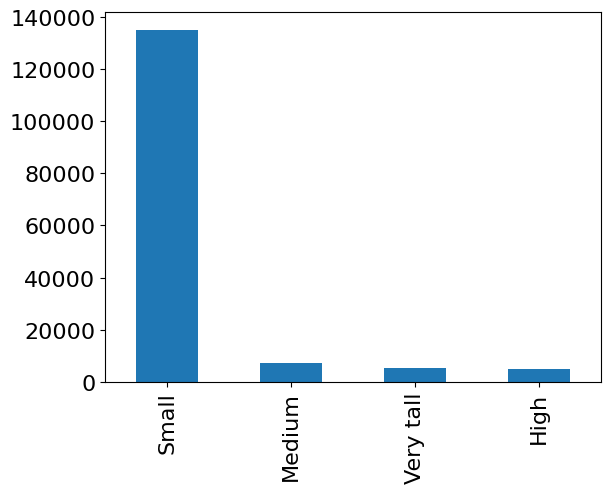

In [170]:
filtered_buildings_df = buildings_df[['building_use', 'n_floors']]
# filtered_buildings_df.groupby(['building_use']).plot(kind='bar')
buildings_df['building_height'] = pd.cut(buildings_df['n_floors'], bins = [0,3,5,10,1000],
                                        labels = ['Small', 'Medium', 'High', 'Very tall'])

# buildings_df.groupby(['building_height']).count()
buildings_df['building_height'].value_counts().plot(kind='bar')
